Baixando: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2025.csv


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data\CARGA_ENERGIA_2025.csv salvo com sucesso!


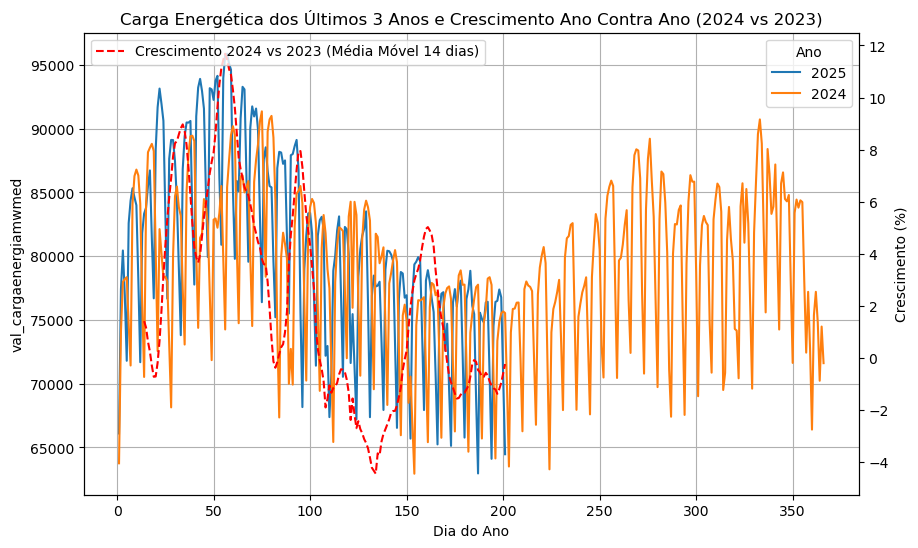

In [133]:
import os
import requests
from datetime import datetime
import matplotlib.pyplot as plt

# Definir a URL base e a pasta de destino
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{}.csv"
dest_folder = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Pasta onde os arquivos serão salvos

# Pegar o ano atual
current_year = datetime.now().year

# Construir a URL para o ano atual
url = base_url.format(current_year)
file_path = os.path.join(dest_folder, f"CARGA_ENERGIA_{current_year}.csv")

# Certificar-se de que a pasta existe
if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

# Tentar baixar o arquivo do ano atual
try:
    print(f"Baixando: {url}")
    response = requests.get(url,verify=False)
    
    # Checar se o download foi bem-sucedido
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f"Arquivo {file_path} salvo com sucesso!")
    else:
        print(f"Falha ao baixar o arquivo para o ano {current_year}. Status code: {response.status_code}")

except Exception as e:
    print(f"Erro ao baixar o arquivo para o ano {current_year}: {e}")


import os
import pandas as pd

# Definir a pasta onde os arquivos CSV estão localizados
folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta

# Listar todos os arquivos CSV na pasta com o nome padronizado
csv_files = [f for f in os.listdir(folder_path) if f.startswith('CARGA_ENERGIA_') and f.endswith('.csv')]

# Lista para armazenar os DataFrames
dfs = []

# Loop para ler cada arquivo CSV
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    # Ler o CSV
    df = pd.read_csv(file_path,sep=';')
    
    # Adicionar o DataFrame à lista
    dfs.append(df)

# Concatenar todos os DataFrames em um único DataFrame
consolidated_df = pd.concat(dfs, ignore_index=True)

# Agrupar por 'din_instante' e somar os valores de 'val_cargaenergiamwmed'
grouped_df = consolidated_df.groupby('din_instante')['val_cargaenergiamwmed'].sum().reset_index()

# Certificar que o din_instante está no formato datetime
grouped_df['din_instante'] = pd.to_datetime(grouped_df['din_instante'])

# Filtrar os últimos 3 anos
current_year = datetime.now().year
years_to_plot = [current_year - i for i in range(2)]

# Adicionar colunas para o ano e dia do ano
grouped_df['year'] = grouped_df['din_instante'].dt.year
grouped_df['day_of_year'] = grouped_df['din_instante'].dt.dayofyear

# Função para remover valores iguais a zero
def remove_zeros(df):
    return df[df['val_cargaenergiamwmed'] > 0]

# Filtrar os dados dos últimos 3 anos e remover valores zero
df_last_3_years = grouped_df[grouped_df['year'].isin(years_to_plot)]
df_last_3_years = remove_zeros(df_last_3_years)

# Criar a figura e o primeiro eixo (para val_cargaenergiamwmed)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotar uma linha para cada um dos últimos 3 anos no primeiro eixo
for year in years_to_plot:
    yearly_data = df_last_3_years[df_last_3_years['year'] == year]
    ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))

# Configurações do primeiro eixo
ax1.set_xlabel('Dia do Ano')
ax1.set_ylabel('val_cargaenergiamwmed')
ax1.set_title('Carga Energética dos Últimos 3 Anos e Crescimento Ano Contra Ano (2024 vs 2023)')
ax1.grid(True)
ax1.legend(title="Ano")

# Criar o segundo eixo (para o crescimento percentual) compartilhando o eixo x
ax2 = ax1.twinx()

# Calcular a média móvel de 7 dias para 2024 e 2023
df_2025 = df_last_3_years[df_last_3_years['year'] == 2025].set_index('day_of_year')
df_2024 = df_last_3_years[df_last_3_years['year'] == 2024].set_index('day_of_year')

# Garantir que temos os mesmos dias em ambos os anos
common_days = df_2025.index.intersection(df_2024.index)

# Calcular a média móvel de 7 dias para os dias em comum
df_2025['moving_avg'] = df_2025['val_cargaenergiamwmed'].rolling(window=14).mean()
df_2024['moving_avg'] = df_2024['val_cargaenergiamwmed'].rolling(window=14).mean()

# Filtrar valores zero antes de calcular o crescimento
df_2025 = df_2025.loc[common_days]
df_2024 = df_2024.loc[common_days]

df_2025 = df_2025[df_2025['moving_avg'] > 0]
df_2024 = df_2024[df_2024['moving_avg'] > 0]

# Calcular o crescimento percentual com base na média móvel de 7 dias
growth = ((df_2025['moving_avg'] - df_2024['moving_avg']) / df_2024['moving_avg']) * 100

# Plotar a linha de crescimento no eixo secundário
ax2.plot(growth.index, growth, label="Crescimento 2024 vs 2023 (Média Móvel 14 dias)", linestyle='--', color='red')

# Configurações do segundo eixo
ax2.set_ylabel('Crescimento (%)')
ax2.legend(loc="upper left")

# Mostrar o gráfico
plt.show()



Baixando: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2025.csv


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Arquivo C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data\CARGA_ENERGIA_2025.csv salvo com sucesso!


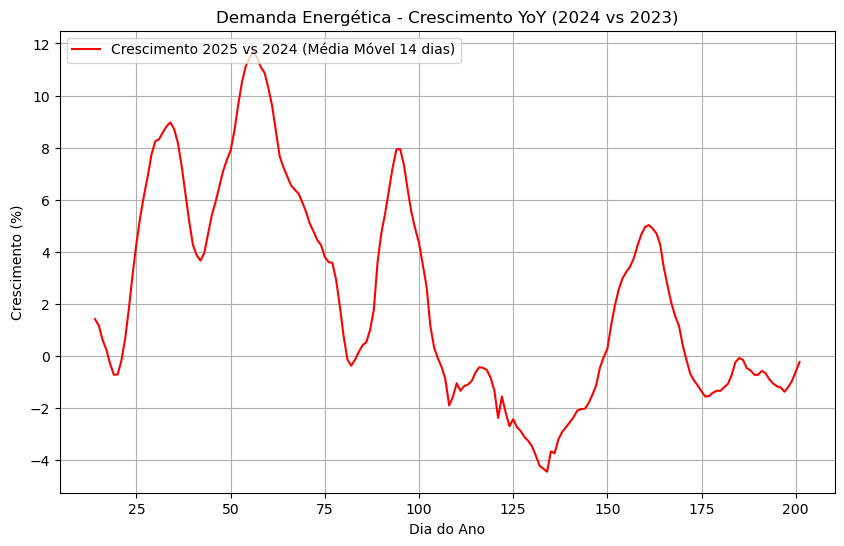

In [3]:
import os
import requests
from datetime import datetime
import matplotlib.pyplot as plt

# Definir a URL base e a pasta de destino
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{}.csv"
dest_folder = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Pasta onde os arquivos serão salvos

# Pegar o ano atual
current_year = datetime.now().year

# Construir a URL para o ano atual
url = base_url.format(current_year)
file_path = os.path.join(dest_folder, f"CARGA_ENERGIA_{current_year}.csv")

# Certificar-se de que a pasta existe
if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

# Tentar baixar o arquivo do ano atual
try:
    print(f"Baixando: {url}")
    response = requests.get(url,verify=False)
    
    # Checar se o download foi bem-sucedido
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f"Arquivo {file_path} salvo com sucesso!")
    else:
        print(f"Falha ao baixar o arquivo para o ano {current_year}. Status code: {response.status_code}")

except Exception as e:
    print(f"Erro ao baixar o arquivo para o ano {current_year}: {e}")


import os
import pandas as pd

# Definir a pasta onde os arquivos CSV estão localizados
folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta

# Listar todos os arquivos CSV na pasta com o nome padronizado
csv_files = [f for f in os.listdir(folder_path) if f.startswith('CARGA_ENERGIA_') and f.endswith('.csv')]

# Lista para armazenar os DataFrames
dfs = []

# Loop para ler cada arquivo CSV
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    # Ler o CSV
    df = pd.read_csv(file_path,sep=';')
    
    # Adicionar o DataFrame à lista
    dfs.append(df)

# Concatenar todos os DataFrames em um único DataFrame
consolidated_df = pd.concat(dfs, ignore_index=True)

# Agrupar por 'din_instante' e somar os valores de 'val_cargaenergiamwmed'
grouped_df = consolidated_df.groupby('din_instante')['val_cargaenergiamwmed'].sum().reset_index()

# Certificar que o din_instante está no formato datetime
grouped_df['din_instante'] = pd.to_datetime(grouped_df['din_instante'])

# Filtrar os últimos 3 anos
current_year = datetime.now().year
years_to_plot = [current_year - i for i in range(2)]

# Adicionar colunas para o ano e dia do ano
grouped_df['year'] = grouped_df['din_instante'].dt.year
grouped_df['day_of_year'] = grouped_df['din_instante'].dt.dayofyear

# Função para remover valores iguais a zero
def remove_zeros(df):
    return df[df['val_cargaenergiamwmed'] > 0]

# Filtrar os dados dos últimos 3 anos e remover valores zero
df_last_3_years = grouped_df[grouped_df['year'].isin(years_to_plot)]
df_last_3_years = remove_zeros(df_last_3_years)

# Criar a figura e o primeiro eixo (para val_cargaenergiamwmed)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotar uma linha para cada um dos últimos 3 anos no primeiro eixo
#for year in years_to_plot:
#    yearly_data = df_last_3_years[df_last_3_years['year'] == year]
#    ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))

# Configurações do primeiro eixo
ax1.set_xlabel('Dia do Ano')
ax1.set_ylabel('Crescimento (%)')
ax1.set_title('Demanda Energética - Crescimento YoY (2024 vs 2023)')
ax1.grid(True)
ax1.legend(title="Ano")

# Criar o segundo eixo (para o crescimento percentual) compartilhando o eixo x
#ax2 = ax1.twinx()

# Calcular a média móvel de 7 dias para 2024 e 2023
df_2025 = df_last_3_years[df_last_3_years['year'] == 2025].set_index('day_of_year')
df_2024 = df_last_3_years[df_last_3_years['year'] == 2024].set_index('day_of_year')

# Garantir que temos os mesmos dias em ambos os anos
common_days = df_2025.index.intersection(df_2024.index)

# Calcular a média móvel de 7 dias para os dias em comum
df_2025['moving_avg'] = df_2025['val_cargaenergiamwmed'].rolling(window=14).mean()
df_2024['moving_avg'] = df_2024['val_cargaenergiamwmed'].rolling(window=14).mean()

# Filtrar valores zero antes de calcular o crescimento
df_2025 = df_2025.loc[common_days]
df_2024 = df_2024.loc[common_days]

df_2025 = df_2025[df_2025['moving_avg'] > 0]
df_2024 = df_2024[df_2024['moving_avg'] > 0]

# Calcular o crescimento percentual com base na média móvel de 7 dias
growth = ((df_2025['moving_avg'] - df_2024['moving_avg']) / df_2024['moving_avg']) * 100

# Plotar a linha de crescimento no eixo secundário
ax1.plot(growth.index, growth, label="Crescimento 2025 vs 2024 (Média Móvel 14 dias)", linestyle='-', color='red')

# Configurações do segundo eixo
#ax2.set_ylabel('Crescimento (%)')
ax1.legend(loc="upper left")

# Mostrar o gráfico
plt.show()



Baixando: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2025.csv


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Arquivo C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data\CARGA_ENERGIA_2025.csv salvo com sucesso!


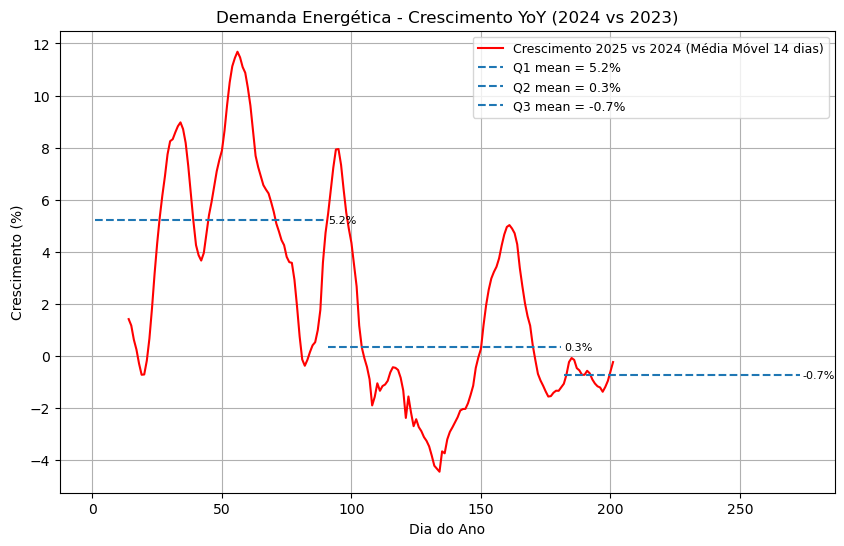

In [135]:
import os
import requests
from datetime import datetime
import matplotlib.pyplot as plt

# Definir a URL base e a pasta de destino
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{}.csv"
dest_folder = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Pasta onde os arquivos serão salvos

# Pegar o ano atual
current_year = datetime.now().year

# Construir a URL para o ano atual
url = base_url.format(current_year)
file_path = os.path.join(dest_folder, f"CARGA_ENERGIA_{current_year}.csv")

# Certificar-se de que a pasta existe
if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

# Tentar baixar o arquivo do ano atual
try:
    print(f"Baixando: {url}")
    response = requests.get(url,verify=False)
    
    # Checar se o download foi bem-sucedido
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f"Arquivo {file_path} salvo com sucesso!")
    else:
        print(f"Falha ao baixar o arquivo para o ano {current_year}. Status code: {response.status_code}")

except Exception as e:
    print(f"Erro ao baixar o arquivo para o ano {current_year}: {e}")


import os
import pandas as pd

# Definir a pasta onde os arquivos CSV estão localizados
folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta

# Listar todos os arquivos CSV na pasta com o nome padronizado
csv_files = [f for f in os.listdir(folder_path) if f.startswith('CARGA_ENERGIA_') and f.endswith('.csv')]

# Lista para armazenar os DataFrames
dfs = []

# Loop para ler cada arquivo CSV
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    # Ler o CSV
    df = pd.read_csv(file_path,sep=';')
    
    # Adicionar o DataFrame à lista
    dfs.append(df)

# Concatenar todos os DataFrames em um único DataFrame
consolidated_df = pd.concat(dfs, ignore_index=True)

# Agrupar por 'din_instante' e somar os valores de 'val_cargaenergiamwmed'
grouped_df = consolidated_df.groupby('din_instante')['val_cargaenergiamwmed'].sum().reset_index()

# Certificar que o din_instante está no formato datetime
grouped_df['din_instante'] = pd.to_datetime(grouped_df['din_instante'])

# Filtrar os últimos 3 anos
current_year = datetime.now().year
years_to_plot = [current_year - i for i in range(2)]

# Adicionar colunas para o ano e dia do ano
grouped_df['year'] = grouped_df['din_instante'].dt.year
grouped_df['day_of_year'] = grouped_df['din_instante'].dt.dayofyear

# Função para remover valores iguais a zero
def remove_zeros(df):
    return df[df['val_cargaenergiamwmed'] > 0]

# Filtrar os dados dos últimos 3 anos e remover valores zero
df_last_3_years = grouped_df[grouped_df['year'].isin(years_to_plot)]
df_last_3_years = remove_zeros(df_last_3_years)

# Criar a figura e o primeiro eixo (para val_cargaenergiamwmed)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotar uma linha para cada um dos últimos 3 anos no primeiro eixo
#for year in years_to_plot:
#    yearly_data = df_last_3_years[df_last_3_years['year'] == year]
#    ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))

# Configurações do primeiro eixo
ax1.set_xlabel('Dia do Ano')
ax1.set_ylabel('Crescimento (%)')
ax1.set_title('Demanda Energética - Crescimento YoY (2024 vs 2023)')
ax1.grid(True)
ax1.legend(title="Ano")

# Criar o segundo eixo (para o crescimento percentual) compartilhando o eixo x
#ax2 = ax1.twinx()

# Calcular a média móvel de 7 dias para 2024 e 2023
df_2025 = df_last_3_years[df_last_3_years['year'] == 2025].set_index('day_of_year')
df_2024 = df_last_3_years[df_last_3_years['year'] == 2024].set_index('day_of_year')

# Garantir que temos os mesmos dias em ambos os anos
common_days = df_2025.index.intersection(df_2024.index)

# Calcular a média móvel de 7 dias para os dias em comum
df_2025['moving_avg'] = df_2025['val_cargaenergiamwmed'].rolling(window=14).mean()
df_2024['moving_avg'] = df_2024['val_cargaenergiamwmed'].rolling(window=14).mean()

# Filtrar valores zero antes de calcular o crescimento
df_2025 = df_2025.loc[common_days]
df_2024 = df_2024.loc[common_days]

df_2025 = df_2025[df_2025['moving_avg'] > 0]
df_2024 = df_2024[df_2024['moving_avg'] > 0]

# Calcular o crescimento percentual com base na média móvel de 7 dias
growth = ((df_2025['moving_avg'] - df_2024['moving_avg']) / df_2024['moving_avg']) * 100

# Plotar a linha de crescimento no eixo secundário
ax1.plot(growth.index, growth, label="Crescimento 2025 vs 2024 (Média Móvel 14 dias)", linestyle='-', color='red')

# Configurações do segundo eixo
#ax2.set_ylabel('Crescimento (%)')
ax1.legend(loc="upper left")

# -------------------------------------------------------------
# ➊  Compute quarterly averages of the YoY‐growth series
# -------------------------------------------------------------
q_boundaries = {           # day-of-year limits for 2025 (non-leap)
    'Q1': (1,   90),       # 1 Jan  – 31 Mar
    'Q2': (91,  181),      # 1 Apr  – 30 Jun
    'Q3': (182, 273),      # 1 Jul  – 30 Sep
    'Q4': (274, 366)       # 1 Oct  – 31 Dec
}

for q, (d_start, d_end) in q_boundaries.items():
    # Seleciona apenas os dias daquele trimestre
    q_mask   = (growth.index >= d_start) & (growth.index <= d_end)
    if not q_mask.any():          # pula se ainda não houver dados
        continue

    q_mean   = growth[q_mask].mean()

    # ---------------------------------------------------------
    # ➋  Desenha linha horizontal (somente dentro do trimestre)
    # ---------------------------------------------------------
    ax1.hlines(y=q_mean,
               xmin=d_start, xmax=d_end,
               linestyles='dashed', linewidth=1.5,
               label=f'{q} mean = {q_mean:.1f}%')

    # Opcional: coloca o rótulo no canto direito da linha
    ax1.text(d_end + 1, q_mean,
             f'{q_mean:.1f}%', va='center', ha='left', fontsize=8)

# -------------------------------------------------------------
# ➌  Atualiza legenda e mostra
# -------------------------------------------------------------
ax1.legend(loc='upper right', fontsize=9)
plt.show()



# Mostrar o gráfico
plt.show()



Baixando: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2025.csv


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Arquivo C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data\CARGA_ENERGIA_2025.csv salvo com sucesso!


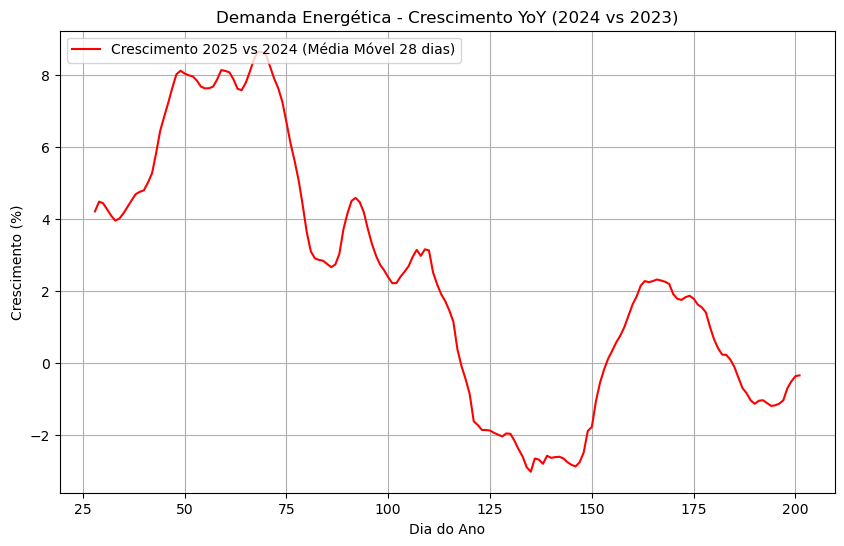

In [5]:
import os
import requests
from datetime import datetime
import matplotlib.pyplot as plt

# Definir a URL base e a pasta de destino
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{}.csv"
dest_folder = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Pasta onde os arquivos serão salvos

# Pegar o ano atual
current_year = datetime.now().year

# Construir a URL para o ano atual
url = base_url.format(current_year)
file_path = os.path.join(dest_folder, f"CARGA_ENERGIA_{current_year}.csv")

# Certificar-se de que a pasta existe
if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

# Tentar baixar o arquivo do ano atual
try:
    print(f"Baixando: {url}")
    response = requests.get(url,verify=False)
    
    # Checar se o download foi bem-sucedido
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f"Arquivo {file_path} salvo com sucesso!")
    else:
        print(f"Falha ao baixar o arquivo para o ano {current_year}. Status code: {response.status_code}")

except Exception as e:
    print(f"Erro ao baixar o arquivo para o ano {current_year}: {e}")


import os
import pandas as pd

# Definir a pasta onde os arquivos CSV estão localizados
folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta

# Listar todos os arquivos CSV na pasta com o nome padronizado
csv_files = [f for f in os.listdir(folder_path) if f.startswith('CARGA_ENERGIA_') and f.endswith('.csv')]

# Lista para armazenar os DataFrames
dfs = []

# Loop para ler cada arquivo CSV
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    # Ler o CSV
    df = pd.read_csv(file_path,sep=';')
    
    # Adicionar o DataFrame à lista
    dfs.append(df)

# Concatenar todos os DataFrames em um único DataFrame
consolidated_df = pd.concat(dfs, ignore_index=True)

# Agrupar por 'din_instante' e somar os valores de 'val_cargaenergiamwmed'
grouped_df = consolidated_df.groupby('din_instante')['val_cargaenergiamwmed'].sum().reset_index()

# Certificar que o din_instante está no formato datetime
grouped_df['din_instante'] = pd.to_datetime(grouped_df['din_instante'])

# Filtrar os últimos 3 anos
current_year = datetime.now().year
years_to_plot = [current_year - i for i in range(2)]

# Adicionar colunas para o ano e dia do ano
grouped_df['year'] = grouped_df['din_instante'].dt.year
grouped_df['day_of_year'] = grouped_df['din_instante'].dt.dayofyear

# Função para remover valores iguais a zero
def remove_zeros(df):
    return df[df['val_cargaenergiamwmed'] > 0]

# Filtrar os dados dos últimos 3 anos e remover valores zero
df_last_3_years = grouped_df[grouped_df['year'].isin(years_to_plot)]
df_last_3_years = remove_zeros(df_last_3_years)

# Criar a figura e o primeiro eixo (para val_cargaenergiamwmed)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotar uma linha para cada um dos últimos 3 anos no primeiro eixo
#for year in years_to_plot:
#    yearly_data = df_last_3_years[df_last_3_years['year'] == year]
#    ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))

# Configurações do primeiro eixo
ax1.set_xlabel('Dia do Ano')
ax1.set_ylabel('Crescimento (%)')
ax1.set_title('Demanda Energética - Crescimento YoY (2024 vs 2023)')
ax1.grid(True)
ax1.legend(title="Ano")

# Criar o segundo eixo (para o crescimento percentual) compartilhando o eixo x
#ax2 = ax1.twinx()

# Calcular a média móvel de 7 dias para 2024 e 2023
df_2025 = df_last_3_years[df_last_3_years['year'] == 2025].set_index('day_of_year')
df_2024 = df_last_3_years[df_last_3_years['year'] == 2024].set_index('day_of_year')

# Garantir que temos os mesmos dias em ambos os anos
common_days = df_2025.index.intersection(df_2024.index)

# Calcular a média móvel de 7 dias para os dias em comum
df_2025['moving_avg'] = df_2025['val_cargaenergiamwmed'].rolling(window=28).mean()
df_2024['moving_avg'] = df_2024['val_cargaenergiamwmed'].rolling(window=28).mean()

# Filtrar valores zero antes de calcular o crescimento
df_2025 = df_2025.loc[common_days]
df_2024 = df_2024.loc[common_days]

df_2025 = df_2025[df_2025['moving_avg'] > 0]
df_2024 = df_2024[df_2024['moving_avg'] > 0]

# Calcular o crescimento percentual com base na média móvel de 7 dias
growth = ((df_2025['moving_avg'] - df_2024['moving_avg']) / df_2024['moving_avg']) * 100

# Plotar a linha de crescimento no eixo secundário
ax1.plot(growth.index, growth, label="Crescimento 2025 vs 2024 (Média Móvel 28 dias)", linestyle='-', color='red')

# Configurações do segundo eixo
#ax2.set_ylabel('Crescimento (%)')
ax1.legend(loc="upper left")

# Mostrar o gráfico
plt.show()



Baixando: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2025.csv


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Arquivo C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data\CARGA_ENERGIA_2025.csv salvo com sucesso!


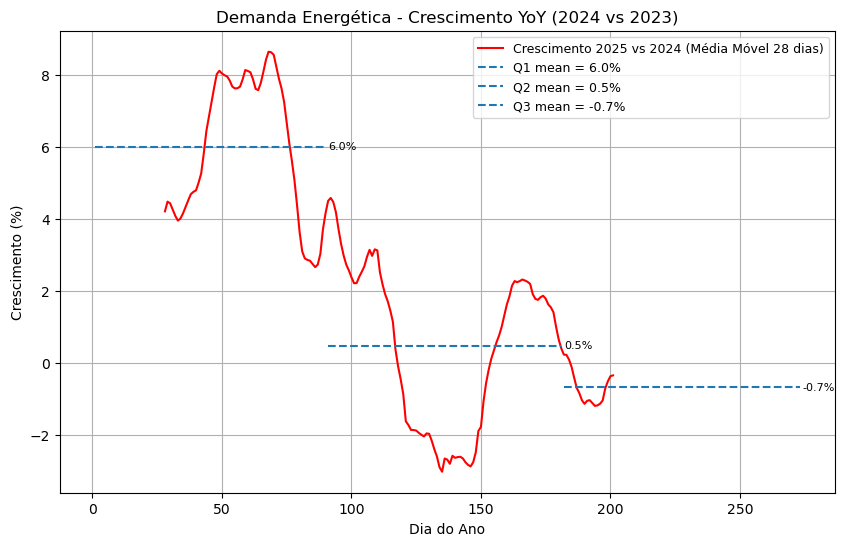

In [6]:
import os
import requests
from datetime import datetime
import matplotlib.pyplot as plt

# Definir a URL base e a pasta de destino
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{}.csv"
dest_folder = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Pasta onde os arquivos serão salvos

# Pegar o ano atual
current_year = datetime.now().year

# Construir a URL para o ano atual
url = base_url.format(current_year)
file_path = os.path.join(dest_folder, f"CARGA_ENERGIA_{current_year}.csv")

# Certificar-se de que a pasta existe
if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

# Tentar baixar o arquivo do ano atual
try:
    print(f"Baixando: {url}")
    response = requests.get(url,verify=False)
    
    # Checar se o download foi bem-sucedido
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f"Arquivo {file_path} salvo com sucesso!")
    else:
        print(f"Falha ao baixar o arquivo para o ano {current_year}. Status code: {response.status_code}")

except Exception as e:
    print(f"Erro ao baixar o arquivo para o ano {current_year}: {e}")


import os
import pandas as pd

# Definir a pasta onde os arquivos CSV estão localizados
folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta

# Listar todos os arquivos CSV na pasta com o nome padronizado
csv_files = [f for f in os.listdir(folder_path) if f.startswith('CARGA_ENERGIA_') and f.endswith('.csv')]

# Lista para armazenar os DataFrames
dfs = []

# Loop para ler cada arquivo CSV
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    # Ler o CSV
    df = pd.read_csv(file_path,sep=';')
    
    # Adicionar o DataFrame à lista
    dfs.append(df)

# Concatenar todos os DataFrames em um único DataFrame
consolidated_df = pd.concat(dfs, ignore_index=True)

# Agrupar por 'din_instante' e somar os valores de 'val_cargaenergiamwmed'
grouped_df = consolidated_df.groupby('din_instante')['val_cargaenergiamwmed'].sum().reset_index()

# Certificar que o din_instante está no formato datetime
grouped_df['din_instante'] = pd.to_datetime(grouped_df['din_instante'])

# Filtrar os últimos 3 anos
current_year = datetime.now().year
years_to_plot = [current_year - i for i in range(2)]

# Adicionar colunas para o ano e dia do ano
grouped_df['year'] = grouped_df['din_instante'].dt.year
grouped_df['day_of_year'] = grouped_df['din_instante'].dt.dayofyear

# Função para remover valores iguais a zero
def remove_zeros(df):
    return df[df['val_cargaenergiamwmed'] > 0]

# Filtrar os dados dos últimos 3 anos e remover valores zero
df_last_3_years = grouped_df[grouped_df['year'].isin(years_to_plot)]
df_last_3_years = remove_zeros(df_last_3_years)

# Criar a figura e o primeiro eixo (para val_cargaenergiamwmed)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotar uma linha para cada um dos últimos 3 anos no primeiro eixo
#for year in years_to_plot:
#    yearly_data = df_last_3_years[df_last_3_years['year'] == year]
#    ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))

# Configurações do primeiro eixo
ax1.set_xlabel('Dia do Ano')
ax1.set_ylabel('Crescimento (%)')
ax1.set_title('Demanda Energética - Crescimento YoY (2024 vs 2023)')
ax1.grid(True)
ax1.legend(title="Ano")

# Criar o segundo eixo (para o crescimento percentual) compartilhando o eixo x
#ax2 = ax1.twinx()

# Calcular a média móvel de 7 dias para 2024 e 2023
df_2025 = df_last_3_years[df_last_3_years['year'] == 2025].set_index('day_of_year')
df_2024 = df_last_3_years[df_last_3_years['year'] == 2024].set_index('day_of_year')

# Garantir que temos os mesmos dias em ambos os anos
common_days = df_2025.index.intersection(df_2024.index)

# Calcular a média móvel de 7 dias para os dias em comum
df_2025['moving_avg'] = df_2025['val_cargaenergiamwmed'].rolling(window=28).mean()
df_2024['moving_avg'] = df_2024['val_cargaenergiamwmed'].rolling(window=28).mean()

# Filtrar valores zero antes de calcular o crescimento
df_2025 = df_2025.loc[common_days]
df_2024 = df_2024.loc[common_days]

df_2025 = df_2025[df_2025['moving_avg'] > 0]
df_2024 = df_2024[df_2024['moving_avg'] > 0]

# Calcular o crescimento percentual com base na média móvel de 7 dias
growth = ((df_2025['moving_avg'] - df_2024['moving_avg']) / df_2024['moving_avg']) * 100

# Plotar a linha de crescimento no eixo secundário
ax1.plot(growth.index, growth, label="Crescimento 2025 vs 2024 (Média Móvel 28 dias)", linestyle='-', color='red')

# Configurações do segundo eixo
#ax2.set_ylabel('Crescimento (%)')
ax1.legend(loc="upper left")

# -------------------------------------------------------------
# ➊  Compute quarterly averages of the YoY‐growth series
# -------------------------------------------------------------
q_boundaries = {           # day-of-year limits for 2025 (non-leap)
    'Q1': (1,   90),       # 1 Jan  – 31 Mar
    'Q2': (91,  181),      # 1 Apr  – 30 Jun
    'Q3': (182, 273),      # 1 Jul  – 30 Sep
    'Q4': (274, 366)       # 1 Oct  – 31 Dec
}

for q, (d_start, d_end) in q_boundaries.items():
    # Seleciona apenas os dias daquele trimestre
    q_mask   = (growth.index >= d_start) & (growth.index <= d_end)
    if not q_mask.any():          # pula se ainda não houver dados
        continue

    q_mean   = growth[q_mask].mean()

    # ---------------------------------------------------------
    # ➋  Desenha linha horizontal (somente dentro do trimestre)
    # ---------------------------------------------------------
    ax1.hlines(y=q_mean,
               xmin=d_start, xmax=d_end,
               linestyles='dashed', linewidth=1.5,
               label=f'{q} mean = {q_mean:.1f}%')

    # Opcional: coloca o rótulo no canto direito da linha
    ax1.text(d_end + 1, q_mean,
             f'{q_mean:.1f}%', va='center', ha='left', fontsize=8)

# -------------------------------------------------------------
# ➌  Atualiza legenda e mostra
# -------------------------------------------------------------
ax1.legend(loc='upper right', fontsize=9)
plt.show()

# Mostrar o gráfico
plt.show()



In [141]:
import os
import requests
import pandas as pd
from datetime import datetime

# Função para baixar o arquivo mais recente (CURVA_CARGA_X.csv)
def download_latest_curve_file():
    current_year = datetime.now().year
    file_name = f"CURVA_CARGA_{current_year}.csv"
    url = f"https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/curva-carga-ho/{file_name}"
    folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta
    file_path = os.path.join(folder_path, file_name)
    
    # Baixar o arquivo mais recente e sobrescrever o arquivo existente
    try:
        print(f"Baixando {file_name} de {url}")
        response = requests.get(url,verify=False)
        response.raise_for_status()  # Verifica se houve erros no download
        with open(file_path, 'wb') as f:
            f.write(response.content)
        print(f"Arquivo {file_name} baixado com sucesso e sobrescrito na pasta.")
    except requests.exceptions.RequestException as e:
        print(f"Erro ao baixar o arquivo {file_name}: {e}")
    
    return file_path

# Função para ler todos os arquivos CURVA_CARGA_X na pasta
def read_all_curve_files():
    folder_path = r"C:\Users\joao.barbosa\Codigos\Carga\Data\raw_data"  # Substitua pelo caminho correto da pasta
    
    # Listar todos os arquivos CSV na pasta que seguem o padrão CURVA_CARGA_X.csv
    csv_files = [f for f in os.listdir(folder_path) if f.startswith('CURVA_CARGA_') and f.endswith('.csv')]
    
    # Lista para armazenar os DataFrames
    dfs = []
    
    # Ler e concatenar todos os arquivos CSV
    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path,sep=";")
        dfs.append(df)
    
    # Concatenar todos os DataFrames lidos em um único DataFrame
    if dfs:
        consolidated_df = pd.concat(dfs, ignore_index=True)
        print(f"Total de {len(csv_files)} arquivos lidos e consolidados.")
    else:
        consolidated_df = pd.DataFrame()
        print("Nenhum arquivo encontrado para leitura.")
    
    return consolidated_df

# Passo 1: Baixar o último arquivo disponível
download_latest_curve_file()

# Passo 2: Ler todos os arquivos CURVA_CARGA_X da pasta
consolidated_df = read_all_curve_files()

# Mostrar as primeiras linhas do DataFrame consolidado
#print(consolidated_df.head())


Baixando CURVA_CARGA_2025.csv de https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/curva-carga-ho/CURVA_CARGA_2025.csv


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo CURVA_CARGA_2025.csv baixado com sucesso e sobrescrito na pasta.
Total de 11 arquivos lidos e consolidados.


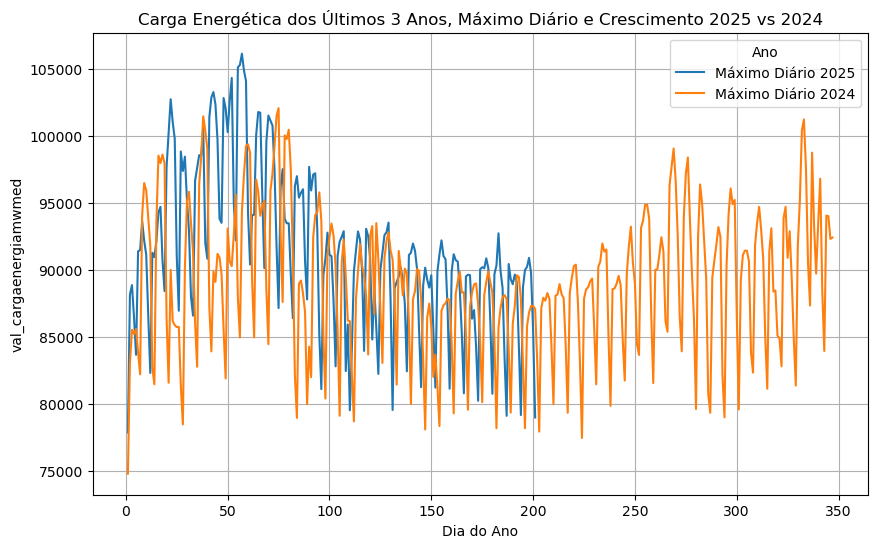

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Função para processar os dados de CURVA_CARGA, agrupando por ano e dia do ano
def process_curve_data(consolidated_df):
    # Converter 'din_instante' para datetime
    consolidated_df['din_instante'] = pd.to_datetime(consolidated_df['din_instante'])
    
    # Criar colunas com o ano e o dia do ano
    consolidated_df['year'] = consolidated_df['din_instante'].dt.year
    consolidated_df['day_of_year'] = consolidated_df['din_instante'].dt.dayofyear

    # Agrupar por 'din_instante' e somar os valores de 'val_cargaenergiahomwmed'
    consolidated_df = consolidated_df.groupby(['din_instante', 'year', 'day_of_year'])['val_cargaenergiahomwmed'].sum().reset_index()

    # Agrupar por 'year' e 'day_of_year' para calcular os valores máximos e mínimos para cada dia do ano
    daily_max_min = consolidated_df.groupby(['year', 'day_of_year'])['val_cargaenergiahomwmed'].agg(['max', 'min']).reset_index()
    
    return daily_max_min

# Função para calcular o crescimento ano contra ano usando a média móvel de 7 dias
def calculate_rolling_growth(df_last_3_years):
    df_2024 = df_last_3_years[df_last_3_years['year'] == 2025].set_index('day_of_year')
    df_2023 = df_last_3_years[df_last_3_years['year'] == 2024].set_index('day_of_year')

    # Garantir que temos os mesmos dias em ambos os anos
    common_days = df_2024.index.intersection(df_2023.index)

    # Calcular a média móvel de 7 dias para os dias em comum
    df_2024['moving_avg'] = df_2024['val_cargaenergiamwmed'].rolling(window=14).mean()
    df_2023['moving_avg'] = df_2023['val_cargaenergiamwmed'].rolling(window=14).mean()

    # Calcular o crescimento percentual com base na média móvel de 7 dias
    growth = ((df_2024.loc[common_days, 'moving_avg'] - df_2023.loc[common_days, 'moving_avg']) /
              df_2023.loc[common_days, 'moving_avg']) * 100

    return growth

# Função para plotar os valores máximos, crescimento ano contra ano e os dados de 2023 e 2024
def plot_curve_with_max_and_growth(daily_max_min, df_last_3_years, years_to_plot, growth):
    # Criar a figura e o primeiro eixo (para val_cargaenergiamwmed)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plotar os dados dos anos anteriores (2023, 2024, etc.)
    #for year in years_to_plot:
     #   yearly_data = df_last_3_years[df_last_3_years['year'] == year]
      #  if year == 2024:
            # Plotar a série de 2024 e salvar a cor
       #     line_2024, = ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))
        #    color_2024 = line_2024.get_color()  # Obter a cor da linha de 2024 para usar na linha tracejada
        #else:
         #   ax1.plot(yearly_data['day_of_year'], yearly_data['val_cargaenergiamwmed'], label=str(year))

    # Plotar o valor máximo diário do ano mais recente com a mesma cor de 2024, mas em linha tracejada
    max_data = daily_max_min[daily_max_min['year'] == 2025]
    max_data2 = daily_max_min[daily_max_min['year'] == 2024]
    ax1.plot(max_data['day_of_year'], max_data['max'], label="Máximo Diário 2025", linestyle='-')
    ax1.plot(max_data2['day_of_year'], max_data2['max'], label="Máximo Diário 2024", linestyle='-')

    # Criar o segundo eixo (para o crescimento percentual) compartilhando o eixo x
    #ax2 = ax1.twinx()

    # Plotar o crescimento percentual ano contra ano no eixo secundário
    #ax2.plot(growth.index, growth, label="Crescimento 2024 vs 2023 (Média Móvel 14 dias)", linestyle='--', color='red')

    # Configurações do primeiro eixo
    ax1.set_xlabel('Dia do Ano')
    ax1.set_ylabel('val_cargaenergiamwmed')
    ax1.set_title('Carga Energética dos Últimos 3 Anos, Máximo Diário e Crescimento 2025 vs 2024')
    ax1.grid(True)
    ax1.legend(title="Ano")

    # Configurações do segundo eixo
    #ax2.set_ylabel('Crescimento (%)')
    #ax2.legend(loc="upper left")

    # Mostrar o gráfico
    plt.show()

# Assumindo que consolidated_df é o resultado de todos os arquivos CURVA_CARGA lidos
# consolidated_df = read_all_curve_files()  # Já realizado no passo anterior

# Processar os dados para encontrar o valor máximo e mínimo para cada dia
daily_max_min = process_curve_data(consolidated_df)

# Supomos que df_last_3_years contém os dados de 2023 e 2024 já plotados anteriormente
# years_to_plot = [2023, 2024]  # Pode ser adaptado conforme necessário

# Calcular o crescimento ano contra ano com base na média móvel de 7 dias
growth = calculate_rolling_growth(df_last_3_years)

# Plotar o valor máximo diário e o crescimento ano contra ano junto com os dados dos últimos 3 anos
plot_curve_with_max_and_growth(daily_max_min, df_last_3_years, years_to_plot, growth)


In [145]:
def comparar_carga_por_hora(consolidated_df, data_2024, data_2025):
    import matplotlib.pyplot as plt

    # Garantir que a coluna de data está no formato datetime
    consolidated_df['din_instante'] = pd.to_datetime(consolidated_df['din_instante'])

    # Adicionar colunas auxiliares
    consolidated_df['data'] = consolidated_df['din_instante'].dt.date
    consolidated_df['hora'] = consolidated_df['din_instante'].dt.hour

    # Converter strings para datas
    data_2024 = pd.to_datetime(data_2024).date()
    data_2025 = pd.to_datetime(data_2025).date()

    # Filtrar para os dois dias escolhidos
    df_2024 = consolidated_df[consolidated_df['data'] == data_2024]
    df_2025 = consolidated_df[consolidated_df['data'] == data_2025]

    # Agregar por hora somando a carga (caso haja múltiplas entradas por hora)
    carga_2024 = df_2024.groupby('hora')['val_cargaenergiahomwmed'].sum()
    carga_2025 = df_2025.groupby('hora')['val_cargaenergiahomwmed'].sum()

    # Calcular as médias diárias
    media_2024 = carga_2024.mean()
    media_2025 = carga_2025.mean()

    # Cores consistentes
    cor_2024 = "#1f77b4"  # azul
    cor_2025 = "#ff7f0e"  # laranja

    # Plotar o gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(carga_2024.index, carga_2024.values, marker='o', color=cor_2024, label=f'{data_2024}')
    plt.axhline(media_2024, color=cor_2024, linestyle='--', alpha=0.7, label=f'Média {data_2024} = {media_2024:.1f}')

    plt.plot(carga_2025.index, carga_2025.values, marker='o', color=cor_2025, label=f'{data_2025}')
    plt.axhline(media_2025, color=cor_2025, linestyle='--', alpha=0.7, label=f'Média {data_2025} = {media_2025:.1f}')

    # Layout
    plt.title('Comparativo de Carga Horária com Médias Diárias')
    plt.xlabel('Hora do dia')
    plt.ylabel('Carga (MW médios)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


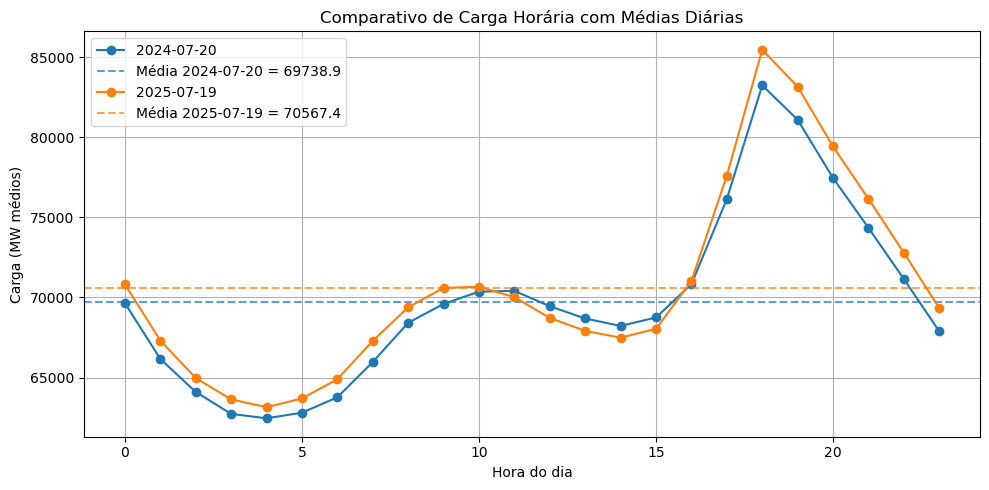

In [149]:
comparar_carga_por_hora(consolidated_df, '2024-07-20', '2025-07-19')
